# Fifty-Two-Week-Range — a quantitative teardown
### Real daily panel · cross-sectional quintiles · paired spread-vs-spread HAC test · Fama-MacBeth spanning regression · block-bootstrap CIs · two-knob synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Better than the high?: Confirmed, but hollow](https://img.shields.io/badge/Better_than_the_high%3F-Confirmed,_but_hollow-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the 52-week **range position** has a standalone cross-sectional edge, and — the study's actual question — whether it carries *incremental* information over the George-Hwang **high ratio** once we control for it.

> **Not investment advice.** Real data: Yahoo daily bars, 20 S&P 500 large-caps (2013-01-02→2026-06-15, **survivorship-biased**); as-of 2026-06-15; the offline core and tests run on a deterministic two-knob synthetic panel. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fifty_two_week_range import data, strategy as st

HAVE_REAL = data.have_real_cache()

def real_panels():
    return data.load_ohlc_panels(allow_survivorship_bias=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Range-position Q5−Q1 spread: 1d *t* = +2.00 (bootstrap CI [+1.2,+22.5] bps, bid-ask-tainted), 5/21/65d *t* = +0.67/+0.32/+0.45; long-only *t* = +0.26. No robust standalone edge. |
| **Tradability** | `MIRAGE` | Largest gross spread +12.8 bps (*t* = +0.32); net turns negative (-7.2 bps) by 20 bps. |
| **Better than the high alone?** | `CONFIRMED` (hollow) | Paired POS−HR difference 5/21/65d *t* = +2.72/+3.42/+4.04; spanning incremental POS\|HR *t* = +2.16 while HR\|POS = -2.26. Range-position wins only because the high ratio is inverted here. |

> In plain words: the second anchor (the low) really does add information over the high alone — but on this sample the high alone is a *losing* signal, so "adds information" buys a relative win, not a tradable one.

## 1 · The claim, steelmanned

Let $P_t$ be the price, $H_t,L_t$ the trailing 252-day high/low. Define

$$\mathrm{pos}_t=\frac{P_t-L_t}{H_t-L_t}\in[0,1],\qquad \mathrm{hr}_t=\frac{P_t}{H_t}\in(0,1].$$

- **H₁ (standalone).** The cross-sectional Q5−Q1 spread on $\mathrm{pos}$ has $\mathbb{E}[\text{spread}]>0$ at HAC *t* ≥ 2.
- **H₂ (incremental, the study's spine).** $\mathrm{pos}$ beats $\mathrm{hr}$: the *paired difference* of their spreads, and the Fama-MacBeth slope on $\mathrm{pos}$ controlling for $\mathrm{hr}$, are positive at *t* ≥ 2.
- **H₃ (tradable).** Any spread survives realistic one-way × NAV costs.

We find **H₁ rejected** (no standalone edge), **H₂ supported but hollow** (pos beats hr only because hr is inverted on this sample), **H₃ rejected** (cost wall).

## 2 · So what? — what rides on each answer

If H₂ held *and* H₁ held, the low would be a genuine free upgrade to a working momentum signal. If H₂ holds but H₁ doesn't — which is what we find — the lesson is subtler and more useful: **a more-elaborate framing can be *measurably better* than a simpler one and still be worthless**, because "better" is relative and the baseline was already underwater. Naming that distinction precisely is the product here.

## 3 · How we'd know — the protocol

- **Signals.** $\mathrm{pos}$ and $\mathrm{hr}$ on trailing 252-day high/low, formed on closes up to *t*.
- **Forward return.** $\log(P_{t+h}/P_t)$, $h\in\{1,5,21,65\}$ — the **one** execution lag, no second shift.
- **Quintile spread.** Equal-weight Q5−Q1 per weekly rebalance; HAC *t* on the series.
- **The horse race.** (a) paired difference of the two spreads on common dates (`diff_tstat`); (b) Fama-MacBeth per-period cross-sectional OLS of forward returns on z-scored $\mathrm{pos}$ and $\mathrm{hr}$ together (`spanning_regression`).
- **Inference.** Newey-West HAC; circular block-bootstrap CIs.
- **Costs.** One-way × NAV; shorts pay borrow via the round-trip charge.
- **Positive control.** Deterministic synthetic panel with two separable knobs — a shared confound (`range_edge`) and the low-only discriminating edge (`low_edge`).

Universe: 20 S&P 500 large-caps, survivorship-biased (named on the Signal axis).

## 4 · The teardown

### 4a · Standalone spread & its bootstrap CI (H₁)

The range-position spread by horizon, with a block-bootstrap CI on the only borderline horizon (1 day).

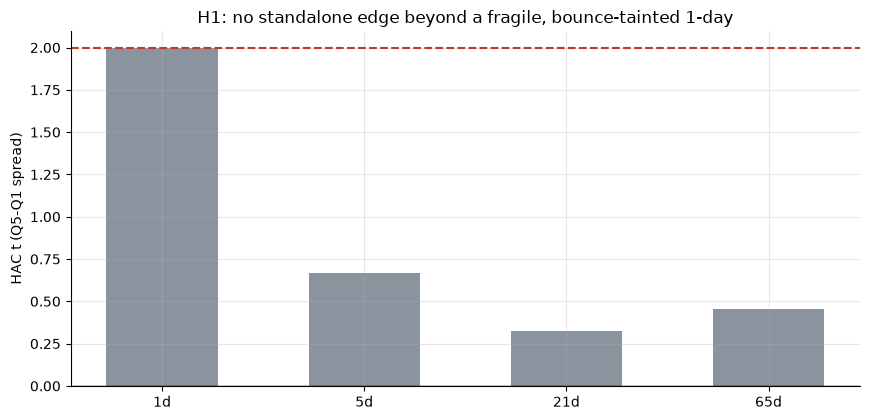

 horizon  mean_bps    t
       1     11.12 2.00
       5      7.42 0.67
      21     12.78 0.32
      65     37.30 0.45
1-day spread bootstrap 95% CI: [+1.2, +22.5] bps


In [2]:
horizons = [1, 5, 21, 65]
if HAVE_REAL:
    close = real_panels()['close']; pos = st.range_position(close)
    recs = []
    for h in horizons:
        fwd = st.forward_returns(close, h)
        s = st.summarize(st.quintile_spread(pos, fwd)['spread_gross'])
        recs.append((h, s['mean_bps'], s['tstat']))
    fwd1 = st.forward_returns(close, 1)
    ci = st.block_bootstrap_ci(st.quintile_spread(pos, fwd1)['spread_gross'].dropna())
else:
    recs = [(1,11.1,2.0),(5,7.4,0.67),(21,12.8,0.32),(65,37.3,0.45)]
    ci = (1.2, 22.5)
dfp = pd.DataFrame(recs, columns=['horizon','mean_bps','t'])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
col = [GREEN if abs(t)>=2 else GREY for t in dfp['t']]
ax.bar(dfp['horizon'].astype(str)+'d', dfp['t'], color=col, width=.55)
ax.axhline(2, ls='--', c=RED); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t (Q5-Q1 spread)')
ax.set_title('H1: no standalone edge beyond a fragile, bounce-tainted 1-day')
plt.tight_layout(); plt.show()
print(dfp.round(2).to_string(index=False))
print(f'1-day spread bootstrap 95% CI: [{ci[0]:+.1f}, {ci[1]:+.1f}] bps')

> 💡 In plain words: the 1-day *t* = +2.00 barely clears the bar and its CI ([+1.2,+22.5] bps) hugs zero — and 1-day cross-sectional spreads are where bid-ask bounce (Roll 1984) masquerades as alpha. Everything longer is noise. **H₁ rejected.**

### 4b · The horse race — paired difference & spanning regression (H₂)

The decisive, *relative* test. Left: the paired POS−HR spread difference per horizon. Right: the Fama-MacBeth incremental slopes (each signal controlling for the other).

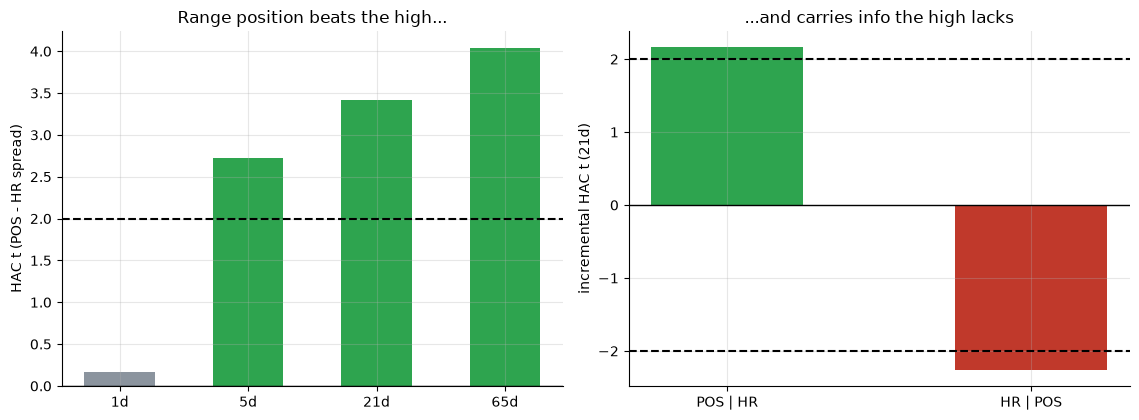

POS-HR diff t: [0.17, 2.72, 3.42, 4.04]
incremental: POS|HR t=+2.16   HR|POS t=-2.26


In [3]:
if HAVE_REAL:
    close = real_panels()['close']
    pos, hr = st.range_position(close), st.high_ratio(close)
    diff_t = []
    for h in horizons:
        fwd = st.forward_returns(close, h)
        qp = st.quintile_spread(pos, fwd); qh = st.quintile_spread(hr, fwd)
        diff_t.append(st.diff_tstat(qp['spread_gross'], qh['spread_gross'])['tstat'])
    fwd21 = st.forward_returns(close, 21)
    inc_pos = st.hac_tstat(st.spanning_regression(pos, hr, fwd21)['b_target'])
    inc_hr  = st.hac_tstat(st.spanning_regression(hr, pos, fwd21)['b_target'])
else:
    diff_t = [0.17, 2.72, 3.42, 4.04]
    inc_pos, inc_hr = 2.16, -2.26
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
c1 = [GREEN if abs(t)>=2 else GREY for t in diff_t]
a1.bar([f'{h}d' for h in horizons], diff_t, color=c1, width=.55)
a1.axhline(2, ls='--', c='k'); a1.axhline(0, c='k', lw=1)
a1.set_ylabel('HAC t (POS - HR spread)'); a1.set_title('Range position beats the high...')
a2.bar(['POS | HR', 'HR | POS'], [inc_pos, inc_hr], color=[GREEN, RED], width=.5)
a2.axhline(2, ls='--', c='k'); a2.axhline(-2, ls='--', c='k'); a2.axhline(0, c='k', lw=1)
a2.set_ylabel('incremental HAC t (21d)'); a2.set_title('...and carries info the high lacks')
plt.tight_layout(); plt.show()
print('POS-HR diff t:', [round(t,2) for t in diff_t])
print(f'incremental: POS|HR t={inc_pos:+.2f}   HR|POS t={inc_hr:+.2f}')

> 💡 In plain words: range position wins the head-to-head (5d *t* = +2.72, 65d +4.04) and the spanning regression agrees — its incremental slope is +2.16 while the high ratio's is **-2.26** (negative!). So **H₂ is supported** — but the high ratio's negative incremental slope is the whole reason: pos wins by *not* loading on a signal that's inverted on this large-cap survivor sample. A relative win over a loser, not an absolute edge. (Recall study 236 already found the George-Hwang anomaly inverted here.)

## 5 · The verdict

- **Signal `NONE`** — pos spread noise except a fragile 1d *t* = +2.00 (CI [+1.2,+22.5] bps); long-only *t* = +0.26.
- **Tradability `MIRAGE`** — gross spread insignificant (*t* = +0.32), negative by 20 bps cost (-7.2 bps, *t* = -0.18).
- **Better than the high? `CONFIRMED` (hollow)** — paired diff *t* up to +4.04, incremental +2.16; but the win is entirely the high ratio's inverted drag.

## 6 · Could you trade it? — the cost wall and the long-only reality

Even granting the largest gross spread, costs (one-way × NAV, shorts paying borrow) finish it; and a long-only investor gains nothing over the basket.

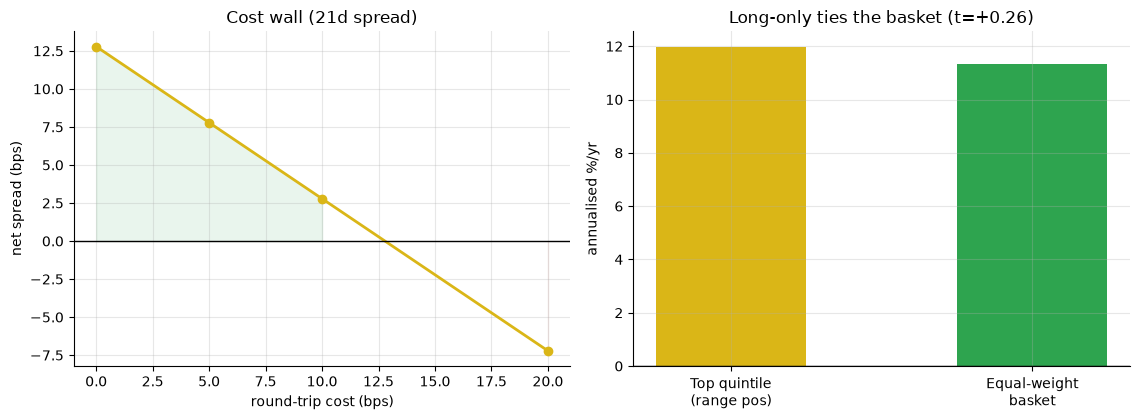

net spread by cost: [12.8, 7.8, 2.8, -7.2] t: [0.32, 0.2, 0.07, -0.18]
long-only +12.0%/yr vs baseline +11.3%/yr (diff t=+0.26)


In [4]:
costs = [0, 5, 10, 20]
if HAVE_REAL:
    close = real_panels()['close']; pos = st.range_position(close)
    fwd21 = st.forward_returns(close, 21)
    net = [st.summarize(st.quintile_spread(pos, fwd21, cost_bps=c)['spread_net']) for c in costs]
    nb = [s['mean_bps'] for s in net]; nt = [s['tstat'] for s in net]
    fwd5 = st.forward_returns(close, 5)
    s5, b5 = st.long_top_decile(pos, fwd5, decile_frac=0.20)
    lo_ann, base_ann, lo_t = st.summarize(s5)['ann_pct'], st.summarize(b5)['ann_pct'], st.diff_tstat(s5,b5)['tstat']
else:
    nb = [12.8, 7.8, 2.8, -7.2]
    nt = [0.32, 0.20, 0.07, -0.18]
    lo_ann, base_ann, lo_t = 12.0, 11.3, 0.26
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
a1.plot(costs, nb, 'o-', c=AMBER, lw=2); a1.axhline(0, c='k', lw=1)
a1.fill_between(costs, nb, 0, where=[v>=0 for v in nb], color=GREEN, alpha=.10)
a1.fill_between(costs, nb, 0, where=[v<0 for v in nb], color=RED, alpha=.10)
a1.set_xlabel('round-trip cost (bps)'); a1.set_ylabel('net spread (bps)')
a1.set_title('Cost wall (21d spread)')
a2.bar(['Top quintile\n(range pos)', 'Equal-weight\nbasket'], [lo_ann, base_ann],
       color=[AMBER, GREEN], width=.5); a2.axhline(0, c='k', lw=1)
a2.set_ylabel('annualised %/yr'); a2.set_title(f'Long-only ties the basket (t={lo_t:+.2f})')
plt.tight_layout(); plt.show()
print('net spread by cost:', [round(v,1) for v in nb], 't:', [round(v,2) for v in nt])
print(f'long-only {lo_ann:+.1f}%/yr vs baseline {base_ann:+.1f}%/yr (diff t={lo_t:+.2f})')

> 💡 In plain words: the gross was never significant, so cost can only worsen it — negative by ~15 bps. And a long-only top quintile earns +12.0%/yr vs the basket's +11.3%/yr (*t* = +0.26): you'd have done as well holding everything. Nothing to protect — **Mirage.**

## 7 · Going further — the two-knob synthetic positive control

Is the *engine* faithful, or does it always declare one signal the winner? Plant (a) a **confound** both signals share and (b) a **discriminating** edge only the low anchor sees, and check the horse race reads each correctly.

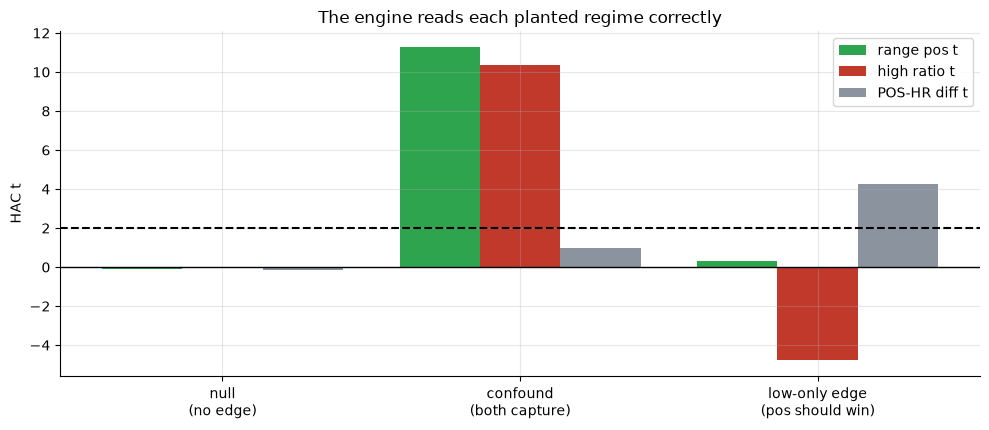

pos t : [-0.09, 11.28, 0.33]
hr  t : [0.03, 10.37, -4.78]
diff t: [-0.17, 0.98, 4.24]


In [5]:
scen = [('null\n(no edge)', 0.0, 0.0),
        ('confound\n(both capture)', 0.004, 0.0),
        ('low-only edge\n(pos should win)', 0.0, 0.01)]
pos_ts, hr_ts, diff_ts = [], [], []
for _, re_, le_ in scen:
    p, _ = data.synthetic_panel(range_edge=re_, low_edge=le_, n_days=1500, seed=331)
    pos, hr = st.range_position(p), st.high_ratio(p)
    fwd = st.forward_returns(p, 5)
    qp = st.quintile_spread(pos, fwd); qh = st.quintile_spread(hr, fwd)
    pos_ts.append(st.summarize(qp['spread_gross'])['tstat'])
    hr_ts.append(st.summarize(qh['spread_gross'])['tstat'])
    diff_ts.append(st.diff_tstat(qp['spread_gross'], qh['spread_gross'])['tstat'])
x = np.arange(len(scen)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.bar(x-w, pos_ts, w, label='range pos t', color=GREEN)
ax.bar(x,   hr_ts, w, label='high ratio t', color=RED)
ax.bar(x+w, diff_ts, w, label='POS-HR diff t', color=GREY)
ax.axhline(2, ls='--', c='k'); ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([s[0] for s in scen])
ax.set_ylabel('HAC t'); ax.legend()
ax.set_title('The engine reads each planted regime correctly')
plt.tight_layout(); plt.show()
print('pos t :', [round(t,2) for t in pos_ts])
print('hr  t :', [round(t,2) for t in hr_ts])
print('diff t:', [round(t,2) for t in diff_ts])

The control passes on all three counts: **null** → both coins, no separation; **confound** → both spreads strong, difference *not* significant (the low adds nothing when the edge is shared); **low-only edge** → range position beats the high ratio. So the real-tape finding is a statement about the market, not a broken pipeline: on this large-cap survivor sample the range anchor has no standalone edge, and its head-to-head win is a hollow consequence of the high ratio being inverted.

Forks worth running: a delisting-aware small-cap panel (where George-Hwang originally lived), and a longer pre-2013 window. See [Study 236](../../236-fifty-two-week-high/) and [Study 202](../../202-fifty-two-week-low/) for the anchors in isolation.